In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
akshit = "\u0905\u0915\u094d\u0937\u093f\u0924"
print(akshit)

अक्षित


In [3]:
#Data collection 
v=  pd.read_csv("temperatures.csv")

In [4]:
v.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
0,1901,22.40,24.14,29.07,31.91,33.41,33.18,31.21,30.39,30.47,29.97,27.31,24.49,28.96,23.27,31.46,31.27,27.25
1,1902,24.93,26.58,29.77,31.78,33.73,32.91,30.92,30.73,29.80,29.12,26.31,24.04,29.22,25.75,31.76,31.09,26.49
2,1903,23.44,25.03,27.83,31.39,32.91,33.00,31.34,29.98,29.85,29.04,26.08,23.65,28.47,24.24,30.71,30.92,26.26
3,1904,22.50,24.73,28.21,32.02,32.64,32.07,30.36,30.09,30.04,29.20,26.36,23.63,28.49,23.62,30.95,30.66,26.40
4,1905,22.00,22.83,26.68,30.01,33.32,33.25,31.44,30.68,30.12,30.67,27.52,23.82,28.30,22.25,30.00,31.33,26.57


In [5]:
v.tail()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
112,2013,24.56,26.59,30.62,32.66,34.46,32.44,31.07,30.76,31.04,30.27,27.83,25.37,29.81,25.58,32.58,31.33,27.83
113,2014,23.83,25.97,28.95,32.74,33.77,34.15,31.85,31.32,30.68,30.29,28.05,25.08,29.72,24.90,31.82,32.00,27.81
114,2015,24.58,26.89,29.07,31.87,34.09,32.48,31.88,31.52,31.55,31.04,28.10,25.67,29.90,25.74,31.68,31.87,28.27
115,2016,26.94,29.72,32.62,35.38,35.72,34.03,31.64,31.79,31.66,31.98,30.11,28.01,31.63,28.33,34.57,32.28,30.03
116,2017,26.45,29.46,31.60,34.95,35.84,33.82,31.88,31.72,32.22,32.29,29.60,27.18,31.42,27.95,34.13,32.41,29.69


In [6]:
v.iloc[0:5,:]

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
0,1901,22.40,24.14,29.07,31.91,33.41,33.18,31.21,30.39,30.47,29.97,27.31,24.49,28.96,23.27,31.46,31.27,27.25
1,1902,24.93,26.58,29.77,31.78,33.73,32.91,30.92,30.73,29.80,29.12,26.31,24.04,29.22,25.75,31.76,31.09,26.49
2,1903,23.44,25.03,27.83,31.39,32.91,33.00,31.34,29.98,29.85,29.04,26.08,23.65,28.47,24.24,30.71,30.92,26.26
3,1904,22.50,24.73,28.21,32.02,32.64,32.07,30.36,30.09,30.04,29.20,26.36,23.63,28.49,23.62,30.95,30.66,26.40
4,1905,22.00,22.83,26.68,30.01,33.32,33.25,31.44,30.68,30.12,30.67,27.52,23.82,28.30,22.25,30.00,31.33,26.57


In [7]:
v.describe()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
count,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000
mean,1959.000000,23.687436,25.597863,29.085983,31.975812,33.565299,32.774274,31.035897,30.507692,30.486752,29.766581,27.285470,24.608291,29.181368,24.629573,31.517607,31.198205,27.208120
std,33.919021,0.834588,1.150757,1.068451,0.889478,0.724905,0.633132,0.468818,0.476312,0.544295,0.705492,0.714518,0.782644,0.555555,0.911239,0.740585,0.420508,0.672003
min,1901.000000,22.000000,22.830000,26.680000,30.010000,31.930000,31.100000,29.760000,29.310000,29.070000,27.900000,25.700000,23.020000,28.110000,22.250000,29.920000,30.240000,25.740000
25%,1930.000000,23.100000,24.780000,28.370000,31.460000,33.110000,32.340000,30.740000,30.180000,30.120000,29.380000,26.790000,24.040000,28.760000,24.110000,31.040000,30.920000,26.700000
50%,1959.000000,23.680000,25.480000,29.040000,31.950000,33.510000,32.730000,31.000000,30.540000,30.520000,29.780000,27.300000,24.660000,29.090000,24.530000,31.470000,31.190000,27.210000
75%,1988.000000,24.180000,26.310000,29.610000,32.420000,34.030000,33.180000,31.330000,30.760000,30.810000,30.170000,27.720000,25.110000,29.470000,25.150000,31.890000,31.400000,27.610000
max,2017.000000,26.940000,29.720000,32.620000,35.380000,35.840000,34.480000,32.760000,31.840000,32.220000,32.290000,30.110000,28.010000,31.630000,28.330000,34.570000,32.410000,30.030000


In [8]:
v.shape

(117, 18)

In [9]:
v.info


<bound method DataFrame.info of      YEAR    JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG    SEP  \
0    1901  22.40  24.14  29.07  31.91  33.41  33.18  31.21  30.39  30.47   
1    1902  24.93  26.58  29.77  31.78  33.73  32.91  30.92  30.73  29.80   
2    1903  23.44  25.03  27.83  31.39  32.91  33.00  31.34  29.98  29.85   
3    1904  22.50  24.73  28.21  32.02  32.64  32.07  30.36  30.09  30.04   
4    1905  22.00  22.83  26.68  30.01  33.32  33.25  31.44  30.68  30.12   
..    ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
112  2013  24.56  26.59  30.62  32.66  34.46  32.44  31.07  30.76  31.04   
113  2014  23.83  25.97  28.95  32.74  33.77  34.15  31.85  31.32  30.68   
114  2015  24.58  26.89  29.07  31.87  34.09  32.48  31.88  31.52  31.55   
115  2016  26.94  29.72  32.62  35.38  35.72  34.03  31.64  31.79  31.66   
116  2017  26.45  29.46  31.60  34.95  35.84  33.82  31.88  31.72  32.22   

       OCT    NOV    DEC  ANNUAL  JAN-FEB  MAR-MAY  JUN

In [10]:
v.isnull().sum()

YEAR       0
JAN        0
FEB        0
MAR        0
APR        0
MAY        0
JUN        0
JUL        0
AUG        0
SEP        0
OCT        0
NOV        0
DEC        0
ANNUAL     0
JAN-FEB    0
MAR-MAY    0
JUN-SEP    0
OCT-DEC    0
dtype: int64

In [11]:
v.corr()



,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
YEAR,1.000000,0.575499,0.647066,0.553886,0.540662,0.407648,0.371840,0.478512,0.654138,0.664008,0.589073,0.697887,0.732222,0.801129,0.679869,0.640438,0.677061,0.749792
JAN,0.575499,1.000000,0.647017,0.457081,0.594674,0.365236,0.292855,0.339337,0.459944,0.499764,0.480695,0.526615,0.595902,0.749880,0.874226,0.575734,0.496515,0.607752
FEB,0.647066,0.647017,1.000000,0.589088,0.548803,0.377722,0.341302,0.418956,0.503188,0.472755,0.466916,0.519595,0.619320,0.792541,0.928731,0.635904,0.544527,0.609839
MAR,0.553886,0.457081,0.589088,1.000000,0.618621,0.387756,0.228349,0.232647,0.382344,0.370066,0.312226,0.498202,0.523316,0.689205,0.584612,0.848637,0.380640,0.505879
APR,0.540662,0.594674,0.548803,0.618621,1.000000,0.563317,0.299866,0.286052,0.490668,0.437970,0.473873,0.538037,0.579775,0.770596,0.643942,0.878402,0.474542,0.596943
MAY,0.407648,0.365236,0.377722,0.387756,0.563317,1.000000,0.274521,0.299072,0.473171,0.347289,0.468993,0.482822,0.444695,0.609015,0.403316,0.708221,0.431314,0.503445
JUN,0.371840,0.292855,0.341302,0.228349,0.299866,0.274521,1.000000,0.480925,0.504354,0.305761,0.380782,0.419968,0.366242,0.520189,0.351115,0.341301,0.749132,0.409325
JUL,0.478512,0.339337,0.418956,0.232647,0.286052,0.299072,0.480925,1.000000,0.622985,0.531865,0.568341,0.535413,0.440813,0.588454,0.423876,0.321388,0.799602,0.541023
AUG,0.654138,0.459944,0.503188,0.382344,0.490668,0.473171,0.504354,0.622985,1.000000,0.680212,0.661177,0.588961,0.595330,0.755384,0.534818,0.560118,0.866202,0.665040
SEP,0.664008,0.499764,0.472755,0.370066,0.437970,0.347289,0.305761,0.531865,0.680212,1.000000,0.680744,0.683866,0.629223,0.730756,0.529533,0.485397,0.778875,0.734650


In [12]:
print(v.columns)


Index(['YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
       'OCT', 'NOV', 'DEC', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP',
       'OCT-DEC'],
      dtype='object')


In [13]:
v.corr()["YEAR"].sort_values(ascending=False)

YEAR       1.000000
ANNUAL     0.801129
OCT-DEC    0.749792
DEC        0.732222
NOV        0.697887
JAN-FEB    0.679869
JUN-SEP    0.677061
SEP        0.664008
AUG        0.654138
FEB        0.647066
MAR-MAY    0.640438
OCT        0.589073
JAN        0.575499
MAR        0.553886
APR        0.540662
JUL        0.478512
MAY        0.407648
JUN        0.371840
Name: YEAR, dtype: float64

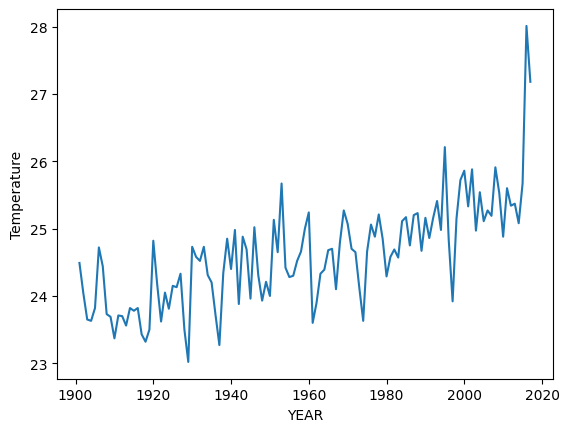

In [14]:
# Highly Correlated (Dec)

plt.plot(v['YEAR'], v['DEC'])
plt.xlabel("YEAR")
plt.ylabel("Temperature")
plt.show()

In [15]:
x = v[["YEAR"]]
y = v[["DEC"]]

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.25, random_state=1)


In [17]:
print("Highly correlated")
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

Highly correlated
(87, 1)
(30, 1)
(87, 1)
(30, 1)


In [18]:
model_h = LinearRegression()
model_h.fit(x_train,y_train)

LinearRegression()

In [19]:
train_predicted = model_h.predict(x_train)
test_predicted = model_h.predict(x_test)

In [20]:
train_sse = np.sum((train_predicted - y_train)**2, axis = 0)
train_sse

DEC    25.708982
dtype: float64

In [21]:
mae = mean_absolute_error(y_train, train_predicted)
mae

0.390804972697165

Text(0, 0.5, 'Temperature')

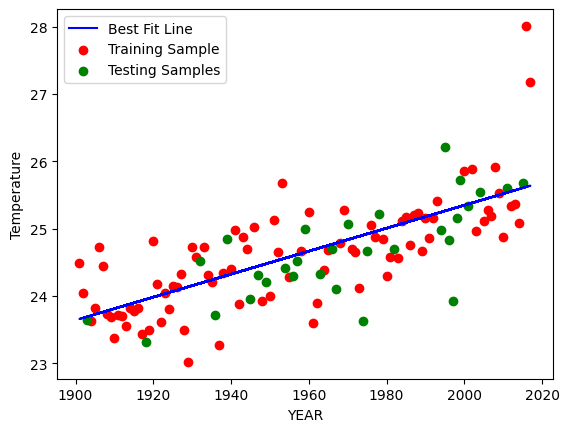

In [22]:
plt.plot(x_train, train_predicted, c = 'b')
plt.scatter(x_train, y_train, c = 'r')
plt.scatter(x_test, y_test, c = 'g')
plt.legend(["Best Fit Line", "Training Sample", "Testing Samples"])
plt.xlabel("YEAR")
plt.ylabel("Temperature")


In [23]:
train_sse = []
test_sse = []

tr_size = 0.1

while tr_size <= 0.9:
    x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = tr_size, random_state=1)
    
    mod = LinearRegression()
    mod.fit(x_train, y_train)
    
    pred_train = mod.predict(x_train)
    pred_test = mod.predict(x_test)
    
    tr_sse = np.sum((pred_train - y_train)**2, axis = 0)
    te_sse = np.sum((pred_test - y_test)**2, axis = 0)
    
    train_sse.append(tr_sse)
    test_sse.append(te_sse)
    
    tr_size += 0.1

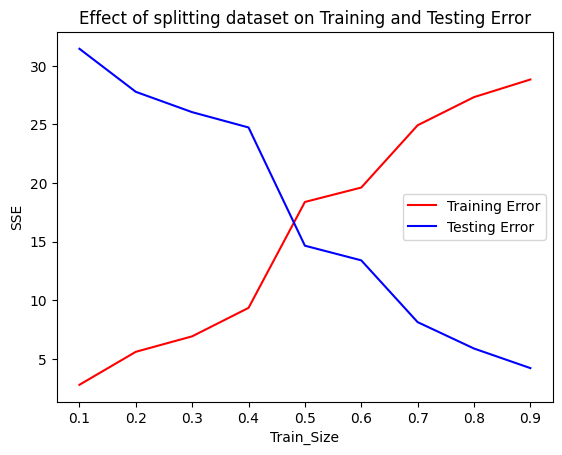

In [24]:
trainSize = []
for i in range(1, 10):
    trainSize.append(i/10)

plt.title("Effect of splitting dataset on Training and Testing Error")
plt.plot(trainSize, np.array(train_sse), c = 'r')
plt.plot(trainSize, np.array(test_sse), c = 'b')

plt.xlabel("Train_Size")
plt.ylabel("SSE")

plt.legend(["Training Error", "Testing Error"])

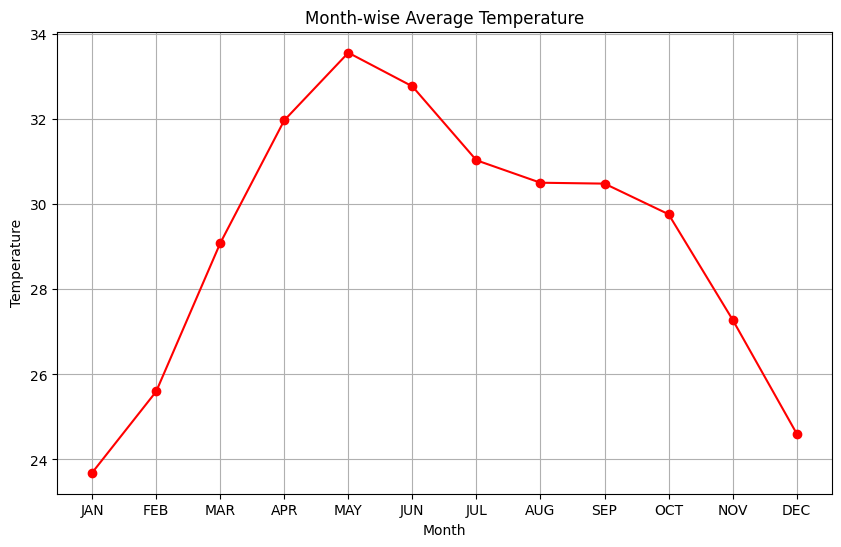

In [25]:
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']#yaha pe maine month naam ki list banayi h
temperature_data = v[months].mean() #mean  temperature for each month across all the years available in the DataFrame v.

temperature_df = temperature_data.reset_index()
#temperature_data is a Pandas Series where the index represents the months,
#.reset_index(): This method converts the Series into a DataFrame by resetting the index, turning the index (months) into a regular column. 
temperature_df.columns = ['Month', 'Temperature']
#This line renames the columns of the DataFrame temperature_df to make them more meaningful.
#temperature_df.columns: Accesses the column names of the DataFrame.
#= ['Month', 'Temperature']: Assigns new names to the columns. 

plt.figure(figsize=(10, 6))
plt.plot(temperature_df['Month'], temperature_df['Temperature'], marker='o',color='red')
plt.title('Month-wise Average Temperature')
plt.xlabel('Month')
plt.ylabel('Temperature')
plt.grid(True)
plt.show()

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Prepare the data for modeling
X = v[['YEAR']]  # Explanatory variable
y = v['ANNUAL']  # Response variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)


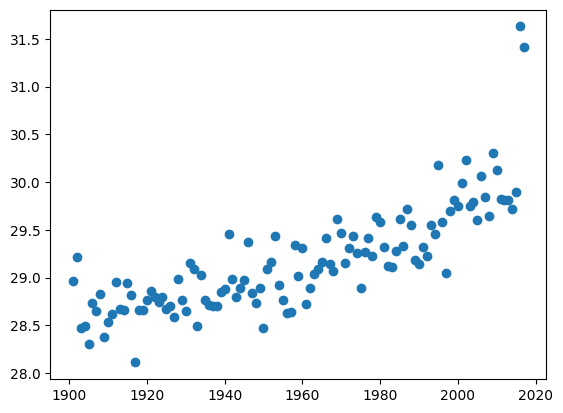

In [27]:
plt.plot(X,y,'o')

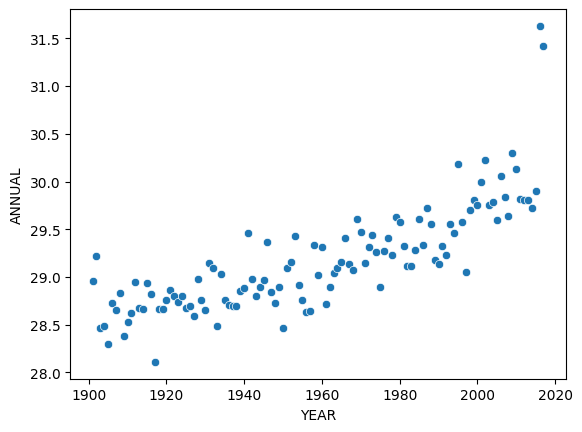

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
x = v["YEAR"]
y = v["ANNUAL"]
df = v  # DataFrame
sns.scatterplot(x=x, y=y, data=df)

# Show the plot
plt.show()

In [29]:
type(x)

pandas.core.series.Series

In [30]:
x.shape

(117,)

In [31]:
x = x.reshape(117,1)

AttributeError: 'Series' object has no attribute 'reshape'

In [ ]:
x = x.values

In [ ]:
x.shape

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.25)

print(f"x Training dataset: {x_train.shape}")
print(f"y Training dataset: {y_train.shape}")
print(f"x test dataset: {x_test.shape}")
print(f"y test dataset: {y_test.shape}")

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train,y_train)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
plt.scatter(x_train, y_train, color='blue')
plt.plot(x_test, y_pred, color='red', linewidth=3)
plt.title("Temperature vs Year")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print(f"MSE:  {mean_squared_error(y_test,y_pred)}")
print(f"MAE:  {mean_absolute_error(y_test,y_pred)}")
print(f"R-Sqaure :  {r2_score(y_test,y_pred)}")

In [ ]:
# Assuming 'Temperature' is the target variable
correlation_matrix = v.corr()
correlated_features = correlation_matrix['ANNUAL'].sort_values(ascending=False)

# Choose the feature with the highest correlation (excluding 'Temperature' itself)
highly_correlated_feature = correlated_features.index[1]  # Assuming the second most correlated feature
print(f'Feature highly correlated with Temperature: {highly_correlated_feature}')


In [ ]:
# Prepare input (X) and output (y) variables
X = v[[highly_correlated_feature]]
y = v['ANNUAL']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


In [ ]:
# Plot the scatter plot and the regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression line')
plt.title('Linear Regression')
plt.xlabel(highly_correlated_feature)
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae:.2f}')

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)
print(f'R-squared Score: {r2:.2f}')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(temperature_df[['Month_Num']])

In [ ]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
# Define features and target variable
X = X_pca
y = temperature_df['Temperature']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)


In [ ]:
plt.figure(figsize=(12, 8))

# Scatter plot for training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Scatter plot for test data
plt.scatter(X_test, y_test, color='green', label='Test Data')

plt.title('Month-wise Average Temperature After PCA Transformation')
plt.xlabel('Principal Component 1')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f'Mean Squared Error: {mse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R-squared Score: {r2:.2f}')

In [ ]:
# Generate a range of values for the principal component
x_range = np.linspace(X_pca.min(), X_pca.max(), 100).reshape(-1, 1)
y_range = model.predict(x_range)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Scatter plot for training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Scatter plot for test data
plt.scatter(X_test, y_test, color='green', label='Test Data')

# Plot the regression line
plt.plot(x_range, y_range, color='red', linewidth=2, label='Regression Line')

plt.title('Month-wise Average Temperature After PCA Transformation')
plt.xlabel('Principal Component 1')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Sample DataFrame creation (assuming temperature_df already exists)
temperature_df['Month_Num'] = np.arange(1, 13)

# Define features and target variable
# Here we are using 'Month_Num' as a feature. In practice, include more features if available.
X = temperature_df[['Month_Num']]  # Features
y = temperature_df['Temperature']   # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R-squared Score: {r2:.2f}')

# Generate predictions for plotting
# Use the entire feature set to get predictions for plotting
y_all_pred = model.predict(X)

# Plotting the data and the regression line
plt.figure(figsize=(12, 8))

# Scatter plot for training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Scatter plot for test data
plt.scatter(X_test, y_test, color='green', label='Test Data')

# Plot the regression line using the entire range of feature values
plt.plot(X, y_all_pred, color='red', linewidth=2, label='Regression Line')

plt.title('Month-wise Average Temperature with Multiple Linear Regression')
plt.xlabel('Month (Numerical)')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
temperature_df['Month_Num'] = np.arange(1, 13)

# Define the features and target variable
X = temperature_df[['Month_Num']]
y = temperature_df['Temperature']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

In [ ]:
# Plotting the data and the regression line
plt.figure(figsize=(12, 8))

# Scatter plot for training data
plt.scatter(X_train, y_train, color='blue', label='Training data')

# Scatter plot for test data
plt.scatter(X_test, y_test, color='green', label='Test data')

# Plot the regression line
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')

plt.title('Month-wise Average Temperature with Linear Regression')
plt.xlabel('Month (Numerical)')
plt.ylabel('Temperature')
plt.xticks(ticks=np.arange(1, 13), labels=temperature_df['Month'], rotation=45)
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R-squared Score: {r2:.2f}')

In [ ]:
plt.figure(figsize=(12, 8))

# Scatter plot for training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Scatter plot for test data
plt.scatter(X_test, y_test, color='green', label='Test Data')

plt.title('Month-wise Average Temperature')
plt.xlabel('Month (Numerical)')
plt.ylabel('Temperature')
plt.xticks(ticks=np.arange(1, 13), labels=temperature_df['Month'], rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(temperature_df['Month_Num'], temperature_df['Temperature'], color='blue', label='Data')
plt.plot(temperature_df['Month_Num'], model.predict(temperature_df[['Month_Num']]), color='red', label='Fitted Line')
plt.title('Month-wise Average Temperature with Fitted Linear Regression Line')
plt.xlabel('Month (Numerical)')
plt.ylabel('Temperature')
plt.xticks(ticks=np.arange(1, 13), labels=temperature_df['Month'], rotation=45)
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Sample DataFrame creation (assuming temperature_df already exists)
# Add more features to the DataFrame
temperature_df['Month_Num'] = np.arange(1, 13)
temperature_df['Another_Feature'] = np.random.rand(12) * 10  # Example feature

# Define features and target variable
X = temperature_df[['Month_Num', 'Another_Feature']]  # Multiple features
y = temperature_df['Temperature']   # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R-squared Score: {r2:.2f}')

# Generate predictions for plotting (using the entire feature set)
y_all_pred = model.predict(X)

# Plotting the data and the regression line
plt.figure(figsize=(12, 8))

# Scatter plot for training data
plt.scatter(X_train['Month_Num'], y_train, color='blue', label='Training Data (Month_Num)')
plt.scatter(X_train['Another_Feature'], y_train, color='purple', label='Training Data (Another_Feature)')

# Scatter plot for test data
plt.scatter(X_test['Month_Num'], y_test, color='green', label='Test Data (Month_Num)')
plt.scatter(X_test['Another_Feature'], y_test, color='orange', label='Test Data (Another_Feature)')

# Plotting regression plane if needed
# For visualization purposes, we'll plot predictions against a grid of feature values
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for training data
ax.scatter(X_train['Month_Num'], X_train['Another_Feature'], y_train, color='blue', label='Training Data')

# Scatter plot for test data
ax.scatter(X_test['Month_Num'], X_test['Another_Feature'], y_test, color='green', label='Test Data')

# Plotting regression plane
x_range = np.linspace(X['Month_Num'].min(), X['Month_Num'].max(), 10)
y_range = np.linspace(X['Another_Feature'].min(), X['Another_Feature'].max(), 10)
X_range, Y_range = np.meshgrid(x_range, y_range)
Z_range = model.predict(np.c_[X_range.ravel(), Y_range.ravel()]).reshape(X_range.shape)
ax.plot_surface(X_range, Y_range, Z_range, color='red', alpha=0.5)

ax.set_xlabel('Month (Numerical)')
ax.set_ylabel('Another Feature')
ax.set_zlabel('Temperature')
ax.set_title('Multiple Linear Regression with Two Features')
ax.legend()
plt.show()
